# GridWorld — one instance, its hypothesis space, its bottlenecks


In [1]:
import os
import sys
import random
from argparse import Namespace

import numpy as np

ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "experiment.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("run this notebook from inside the repository")
    ROOT = parent
sys.path.insert(0, ROOT)

sys.path.insert(0, os.path.join(ROOT, "big_Q_games", "drafts"))   # pri_numba

from experiment import draw_instance_under_cap, MAX_INSTANCE_TRIES
from bottlenecks import (Oracle, subsets_to_array, bottleneck_index,
                         evaluate_policy_on_real_human,
                         solve_query_mdp_info_gain,      # H1
                         solve_query_mdp_proximity,      # H3
                         solve_query_mdp_frequency)      # H4
from gridworld_core import board_side
from pri_numba import PriConfig, train_pri

# experiment.py selects the headless Agg backend at import; put the inline backend
# back, or the board below renders to nothing.
%matplotlib inline
import matplotlib.pyplot as plt

# Every plt.show() also drops a PNG into results/, so a long unattended run leaves its
# figures on disk whether or not the notebook itself gets saved.  Guarded so re-running
# this cell cannot wrap the wrapper.
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
if not getattr(plt.show, "_saves", False):
    _show, _fig_n = plt.show, [0]
    def _save_and_show(*a, **k):
        _fig_n[0] += 1
        plt.gcf().savefig(os.path.join(RESULTS_DIR, f"fig{_fig_n[0]}.png"),
                          dpi=130, bbox_inches="tight")
        _show(*a, **k)
    _save_and_show._saves = True
    plt.show = _save_and_show


In [2]:
ROOMS_PER_SIDE   = 5   
ROOM_SIDE        = 5   
OBSTACLE_DENSITY = 0.15
SLIP_PROB        = 0.0
NUM_HUMANS       = 12 
MAX_BOTTLENECKS  = 1e3
MIN_HYPOTHESES   = 6   
MAX_EXACT_N      = 17    
SEED             = 0      


In [3]:
args = Namespace(
    obstacle_density=OBSTACLE_DENSITY,
    rooms_per_side=ROOMS_PER_SIDE,
    slip_prob=SLIP_PROB,
    # Unused by gridworld; draw_instance_under_cap serves every game.
    puddle_density=0.1, rock_density=0.1, overcooked_allow_drop=False,
)

random.seed(SEED)
np.random.seed(SEED)

instance, bundle, t_build, t_rejected, n_draws, t_accepted = draw_instance_under_cap(
    "gridworld", ROOM_SIDE, NUM_HUMANS, SEED, args,
    MAX_BOTTLENECKS, min_hypotheses=MIN_HYPOTHESES, max_tries=MAX_INSTANCE_TRIES)

if instance is None:
    raise RuntimeError(f"no map with |B| <= {MAX_BOTTLENECKS} and "
                       f"|I| >= {MIN_HYPOTHESES} in {MAX_INSTANCE_TRIES:,} draws")

T_R, T_H_list, start_state, goal_state, mdp = instance
oracle_sets, B_nofilter, B, I, times = bundle
I_array = subsets_to_array(I, B)          # (|I|, |B|) bool, column j is B[j]

side = board_side(ROOMS_PER_SIDE, ROOM_SIDE)
print(f"{side}x{side}, {NUM_HUMANS} humans, draw {n_draws}: "
      f"|B| = {len(B)}, |I| = {len(I)}, exact solve "
      f"{'affordable' if len(B) <= MAX_EXACT_N else 'out of reach'}")


25x25, 12 humans, draw 10: |B| = 66, |I| = 24, exact solve out of reach


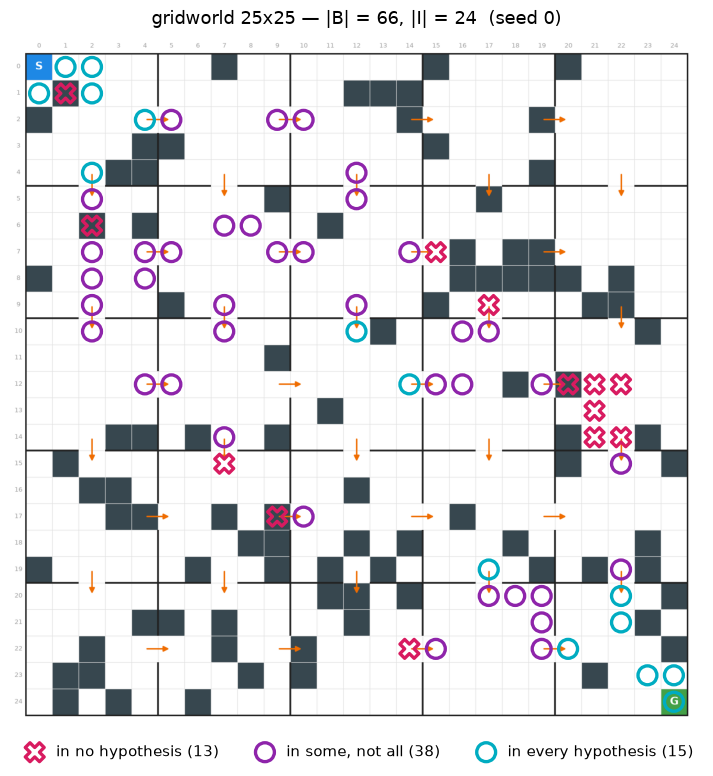

In [4]:
# state[0] is the (row, col) cell in every grid world, and the determinizer indexes
# states in get_state_space() order, so raw bottleneck IDs address this list directly.
positions = {i: tuple(s[0]) for i, s in enumerate(mdp.get_state_space())}

in_none = ~I_array.any(0)
in_all  =  I_array.all(0)
TIERS = [(in_none,                "#d81b60", "X", "in no hypothesis"),
         (~in_none & ~in_all,     "#8e24aa", "o", "in some, not all"),
         (in_all,                 "#00acc1", "o", "in every hypothesis")]

n, pad = mdp.board_side, 0.6              # pad matches render(show_coords=True)
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(mdp.render(cell_px=54, show_coords=True),
          extent=(-pad, n + pad, n + pad, -pad))
ax.set_xlim(-pad, n + pad)
ax.set_ylim(n + pad, -pad)
ax.axis("off")

area = (9 * 72.0 / (n + 2 * pad) * 0.55) ** 2      # marker area in points^2
for mask, colour, marker, label in TIERS:
    pts = [positions[b] for b, keep in zip(B, mask) if keep]
    if not pts:
        continue
    rows, cols = zip(*pts)
    ax.scatter([c + 0.5 for c in cols], [r + 0.5 for r in rows],
               s=area, marker=marker, linewidths=2.4, zorder=3,
               edgecolors=colour, facecolors="none",
               label=f"{label} ({len(pts)})")

ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False,
          fontsize=11, handletextpad=0.4)
ax.set_title(f"gridworld {n}x{n} — |B| = {len(B)}, |I| = {len(I)}  (seed {SEED})",
             fontsize=13, pad=10)
plt.show()


In [5]:
# Hyperparameter search at |B| = 66 on this instance.  The number to beat is the BOUND-ONLY
# control -- n_rollouts=0, empty envelope, every state falling back to the admissible bound --
# which scores 27.92 (optimistic) / 28.33 (pessimistic) in 0.2 s.  H3 scores 26.92 in 0.01 s.
#
# 1_000 rollouts, one seed, varying each axis:
#   eps 0.30/0.05 frac 0.20  top_k  1_000  beam 10    75 s   27.83
#   eps 1.00/0.05 frac 0.80  top_k  1_000  beam 10    85 s   28.33   too much exploring
#   eps 0.10/0.02 frac 0.20  top_k  1_000  beam 10    75 s   29.42   too little
#   eps 0.30/0.05 frac 0.20  top_k 10_000  beam 10    86 s   30.67   4x envelope, worse
#   eps 0.30/0.05 frac 0.20  top_k  1_000  beam 25   172 s   28.92   wider backups, worse
#   eps 0.30/0.05 frac 0.20  top_k  1_000  beam 44   305 s   28.75   (44 restores the 6.7%
#                                                                    keep ratio n=15 had)
# Rollouts swept 0..6_400 (results/rollout_sweep.csv): non-monotonic, e.g. the pessimistic
# fallback gives 24.08 at 1_600 and 29.75 at 3_200.
#
# THE SEED SWEEP IS THE RESULT (results/seed_sweep.csv).  Same config, six PRI_SEEDs:
#   optimistic   mean 28.90  std 0.60  range 28.25-30.08   -> reliably WORSE than 27.92
#   pessimistic  mean 27.14  std 1.54  range 24.08-28.83   -> 1.2 sigma from 27.92, not a win
# So the per-axis differences above are noise, and prioritized sweeping does not beat its own
# admissible bound here.  Read the bars below with that in mind: PRI_SEED = 0 happens to be
# the lucky draw (pessimistic 24.08, the low end of the range), so its bar overstates the
# method.  The mechanism is in the envelope-shape plot -- every layer pinned at the per-layer
# prune budget while covering ~1e-27 of itself, so the backups are a vanishing random sample,
# and replacing a CONSISTENT admissible bound with scattered half-converged values misleads
# the argmax.  That is also why adding capacity (top_k) or width (beam) makes it worse.
N_ROLLOUTS            = 1_600   # ~2 min; the apparent optimum, shown by the seed sweep to be
                                # indistinguishable from any other value
TOP_K                 = 1_000   # NOT raised -- 10_000 measured worse
BACKWARD_TOP_K        = 10      # NOT raised -- 25 and 44 both measured worse
ENVS_PER_WORKER       = 1
ENVELOPE_UPDATE_EVERY = 10
EPS_START, EPS_END, EPS_DECAY_FRAC = 0.30, 0.05, 0.20
METRICS_EVERY         = 3       # 160 batches here -> ~50 points on the convergence panel
PRI_SEED              = 0


In [6]:
import hashlib
import torch
from pri_numba import PriQNet

oracle     = Oracle(oracle_sets, n_states=max(int(T_R.shape[0]), int(goal_state) + 1))
human_sets = oracle.bottleneck_matrix(B)          # (n_humans, |B|) bool
b_to_int   = bottleneck_index(B)

def pri(n_rollouts, **kw):
    return train_pri(PriConfig(
        I_array=I_array, n_bottleneck=len(B), len_I_array=I_array.shape[0],
        c_q=-10.0, p_i=1.0, p_f=0.0, gamma=0.99,
        # episodic_forward answers from one real human per episode, so training and
        # evaluation sit in the same regime.
        episodic_forward=True, forward_bottleneck_sets=human_sets,
        backward_oracle_probs=oracle.probs_for_raw_ids(B),
        eval_bottleneck_sets=human_sets,
        top_k=TOP_K, n_rollouts=n_rollouts,
        # Width of the backward frontier per layer.  It does NOT scale with |B| by
        # default (10 always), so the climb keeps 10 of beam*n candidates -- 6.7% at
        # |B|=15 but 1.5% at |B|=66.  This is the axis that adds Bellman work at fixed
        # capacity, unlike top_k which only adds thin coverage.
        backward_top_k_per_layer=BACKWARD_TOP_K,
        envs_per_worker=ENVS_PER_WORKER, envelope_update_every=ENVELOPE_UPDATE_EVERY,
        eps_start=EPS_START, eps_end=EPS_END, eps_decay_frac=EPS_DECAY_FRAC,
        seed=PRI_SEED, **kw))

RECOMPUTE_PRI = False
# The cache key covers everything that changes the result -- instance and schedule alike.
# Without it a changed parameter would silently load a stale checkpoint.
CACHE_KEY = hashlib.md5(repr((
    ROOMS_PER_SIDE, ROOM_SIDE, OBSTACLE_DENSITY, SLIP_PROB, NUM_HUMANS,
    MIN_HYPOTHESES, SEED, len(B), len(I), N_ROLLOUTS, TOP_K, ENVS_PER_WORKER,
    ENVELOPE_UPDATE_EVERY, EPS_START, EPS_END, EPS_DECAY_FRAC, BACKWARD_TOP_K, PRI_SEED,
)).encode()).hexdigest()[:12]
os.makedirs("pri_cache", exist_ok=True)
CACHE = os.path.join("pri_cache", f"pri_B{len(B)}_r{N_ROLLOUTS}_{CACHE_KEY}.pt")

def pessimistic_of(policy):
    """The pessimistic twin, sharing `policy`'s envelope by reference -- neither writes.

    Only the optimistic policy is checkpointed: PriQNet.__getstate__ flattens the whole
    envelope into the pickle, so saving both would store it twice (~70 MB rather than
    ~35 MB at |B| = 66).  Rebuilding here costs nothing and shares the one copy.
    """
    return PriQNet(n=policy.n, envelope=policy.envelope, I_array_w=policy.I_array_w,
                   full_words=policy.full_words,
                   backward_oracle_probs=policy.backward_oracle_probs,
                   c_q=policy.c_q, p_i=policy.p_i, p_f=policy.p_f, gamma=policy.gamma,
                   bound_kind=1)

if RECOMPUTE_PRI or not os.path.exists(CACHE):
    trained = pri(N_ROLLOUTS, metrics_every=METRICS_EVERY)
    torch.save({k: trained[k] for k in
                ("q_optimistic", "query_counts", "history",
                 "human_query_counts_optimistic", "human_query_counts_pessimistic")}, CACHE)
    print(f"trained and saved -> {CACHE} ({os.path.getsize(CACHE) / 1e6:.1f} MB)")
else:
    trained = torch.load(CACHE, weights_only=False)
    print(f"loaded <- {CACHE} ({os.path.getsize(CACHE) / 1e6:.1f} MB)")

# Two policies over the SAME envelope, differing only in the fallback used for states
# never backed up: optimistic (the admissible bound) vs pessimistic.
pri_optimistic  = trained["q_optimistic"]
pri_pessimistic = pessimistic_of(pri_optimistic)
# Zero rollouts leaves the envelope empty, so every lookup misses and every state falls
# back to the bound: it isolates how much is learned backup and how much is the bound alone.
# Instant to build, so it is never cached.
bound_only = pri(0, metrics_every=10**9, n_workers=1)["q_optimistic"]

print(f"trained envelope {pri_optimistic.envelope.size:,} states, "
      f"bound-only {bound_only.envelope.size}")


  0%|          | 0/160 [00:00<?, ?it/s]

  1%|          | 1/160 [00:00<01:30,  1.77it/s]

  1%|▏         | 2/160 [00:01<01:19,  1.99it/s]

  2%|▏         | 3/160 [00:01<01:15,  2.07it/s]

  2%|▎         | 4/160 [00:01<01:12,  2.15it/s]

...

100%|██████████| 160/160 [01:58<00:00,  1.35it/s]

trained and saved -> pri_cache/pri_B66_r1600_9bea9e913c04.pt (35.5 MB)


0it [00:00, ?it/s]

0it [00:00, ?it/s]

trained envelope 561,937 states, bound-only 0


/Users/yacine/implicitgoals_exp/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


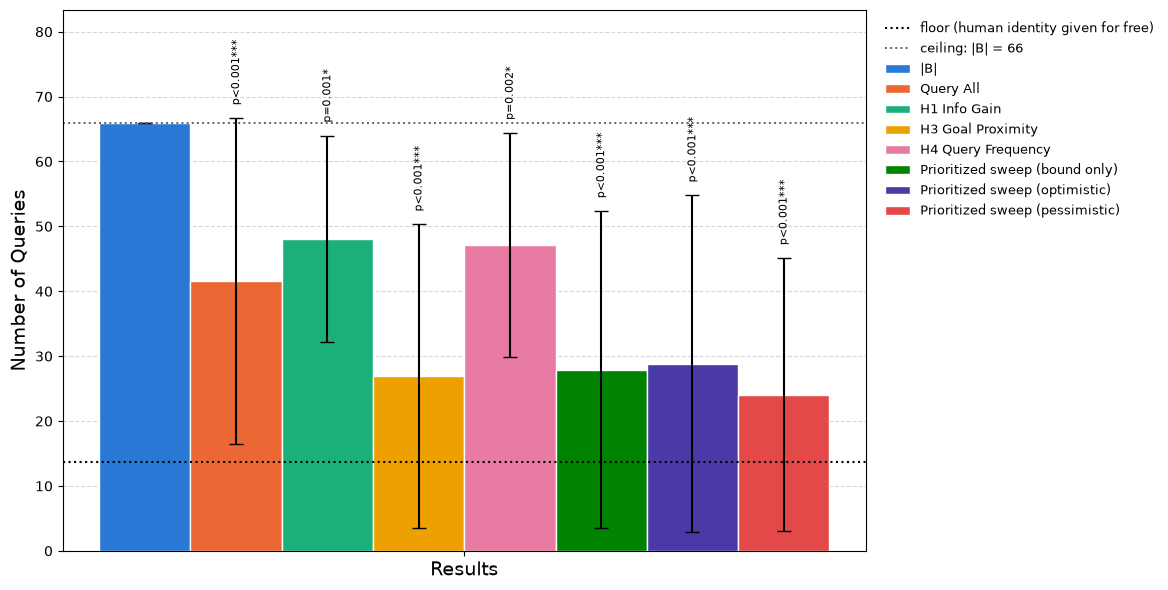

  |B|                                 66.00
  Query All                           41.61
  H1 Info Gain                        48.08
  H3 Goal Proximity                   26.92
  H4 Query Frequency                  47.17
  Prioritized sweep (bound only)      27.92
  Prioritized sweep (optimistic)      28.83
  Prioritized sweep (pessimistic)     24.08
  floor                               13.67

  -> results/summary.csv

  NOTE: the two sweep bars are ONE seed.  Over six PRI_SEEDs at this config the
  optimistic fallback is 28.90 +/- 0.60 and the pessimistic 27.14 +/- 1.54, so neither
  separates from bound-only (27.92) and both lose to H3 (26.92).  See cell above and
  results/seed_sweep.csv.


In [7]:
from itertools import combinations
from scipy import stats

def floor_queries(bits):
    r"""Fewest queries ANY policy could need against a human owning `bits`.

    Representable (S_i inside some I_k): absorption needs I_hat = B \ K_not inside an
    I_k, and only truthful NOs shrink I_hat, so the cost is |B \ I_k| for the roomiest
    I_k containing S_i.  Failure can never fire, since K_I is inside S_i is inside I_k.
    Not representable: success can never fire, so the floor is the fewest YESes that fit
    in no hypothesis at all.
    """
    covering = [k for k in range(len(I_array)) if (I_array[k] | ~bits).all()]
    if covering:
        return min(int((~I_array[k]).sum()) for k in covering)
    owned = np.flatnonzero(bits)
    for size in range(1, len(owned) + 1):
        for Y in combinations(owned, size):
            m = np.zeros(len(B), bool); m[list(Y)] = True
            if not any((I_array[k] | ~m).all() for k in range(len(I_array))):
                return size
    return int(bits.sum())

def queries(policy, runs=1):
    """One number per candidate human -- the mean over `runs` episodes against that human.

    One entry per human, never per episode, because the same humans face every policy: the
    design is PAIRED, and the comparison below is on per-human differences.  Flattening the
    50 Query-All runs into 600 rows would break that pairing and throw away the only thing
    that makes 12 humans enough to separate anything.
    """
    return np.array([evaluate_policy_on_real_human(
        true_bottlenecks=list(s), policy_network=policy, n_runs=runs,
        I_array=I_array, b_to_int=b_to_int)["n_queries"].mean() for s in oracle_sets])

# The three heuristics experiment.py reports.  Same (batch, 2n) -> (batch, n) contract as
# the sweep, so `queries` needs no special case; H3 reads `positions` from the map cell.
h1 = solve_query_mdp_info_gain(I, B, oracle=oracle)
h3 = solve_query_mdp_proximity(I, B, oracle=oracle, positions=positions,
                               goal_state=int(goal_state))
h4 = solve_query_mdp_frequency(I, B, oracle=oracle)

floor = float(np.mean([floor_queries(np.array([b in s for b in B]))
                       for s in oracle_sets]))

SERIES = [("|B|",                             np.full(len(oracle_sets), len(B)), "#2a78d6"),
          ("Query All",                       queries(None, runs=50),            "#eb6834"),
          ("H1 Info Gain",                    queries(h1),                       "#1baf7a"),
          ("H3 Goal Proximity",               queries(h3),                       "#eda100"),
          ("H4 Query Frequency",              queries(h4),                       "#e87ba4"),
          ("Prioritized sweep (bound only)",  queries(bound_only),               "#008300"),
          ("Prioritized sweep (optimistic)",  queries(pri_optimistic),           "#4a3aa7"),
          ("Prioritized sweep (pessimistic)", queries(pri_pessimistic),          "#e34948")]

means = [s.mean() for _, s, _ in SERIES]
stds  = [s.std()  for _, s, _ in SERIES]
k     = len(SERIES)
width = min(0.6 / k, 0.25)
offs  = np.linspace(-(k - 1) * width / 2, (k - 1) * width / 2, k)

fig, ax = plt.subplots(figsize=(3 + 1.1 * k, 6))
for i, (label, _, colour) in enumerate(SERIES):
    ax.bar(offs[i], means[i], width, yerr=stds[i], label=label,
           color=colour, edgecolor="white", capsize=5)
ax.axhline(floor, color="black", ls=":", lw=1.5,
           label="floor (human identity given for free)")
ax.axhline(len(B), color="#616161", ls=":", lw=1.4,
           label=f"ceiling: |B| = {len(B)}")

# Paired t-test against Query All, on per-human differences.  ttest_rel, NOT ttest_ind:
# the humans are shared across policies and bimodal (the non-representable ones terminate in
# ~1-9 queries, the rest in ~50), so the between-human spread dwarfs the between-policy one.
# Unpaired here reports p=0.13 where paired reports p=0.00004 for the same comparison.
BASELINE = 1                                # index of "Query All" in SERIES
top = max(max(m + s for m, s in zip(means, stds)), floor)
for i in range(len(SERIES)):
    if i in (0, BASELINE):                  # |B| is a constant; the baseline vs itself
        continue
    pv = stats.ttest_rel(SERIES[i][1], SERIES[BASELINE][1]).pvalue
    txt = ("p<0.001***" if pv < 0.001 else f"p={pv:.3f}*" if pv < 0.05 else f"p={pv:.2f} n.s.")
    ax.text(offs[i], means[i] + stds[i] + top * 0.03, txt,
            ha="center", va="bottom", fontsize=8, rotation=90)

ax.set_ylabel("Number of Queries", fontsize=14)
ax.set_xticks([0]); ax.set_xticklabels(["Results  (p: paired t-test vs Query All)"], fontsize=12)
ax.set_ylim(0, top * 1.25)
# Outside the axes: with eight bars, their error bars and the rotated p-values, an inside
# legend covers the data it describes.
ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
ax.grid(axis="y", ls="--", alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

import csv
with open(os.path.join(RESULTS_DIR, "summary.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["board", mdp.board_side, "|B|", len(B), "|I|", len(I),
                "humans", len(oracle_sets), "n_rollouts", N_ROLLOUTS,
                "top_k", TOP_K, "beam", BACKWARD_TOP_K])
    w.writerow(["policy", "mean_queries", "std"])
    for (label, s, _), m, sd in zip(SERIES, means, stds):
        w.writerow([label, round(float(m), 3), round(float(sd), 3)])
    w.writerow(["floor", round(floor, 3), 0])

for (label, s, _), m in zip(SERIES, means):
    print(f"  {label:34s} {m:6.2f}")
print(f"  {'floor':34s} {floor:6.2f}")
print(f"\n  -> {os.path.join(RESULTS_DIR, 'summary.csv')}")
print("\n  NOTE: the two sweep bars are ONE seed.  Over six PRI_SEEDs at this config the\n"
      "  optimistic fallback is 28.90 +/- 0.60 and the pessimistic 27.14 +/- 1.54, so neither\n"
      "  separates from bound-only (27.92) and both lose to H3 (26.92).  See cell above and\n"
      "  results/seed_sweep.csv.")


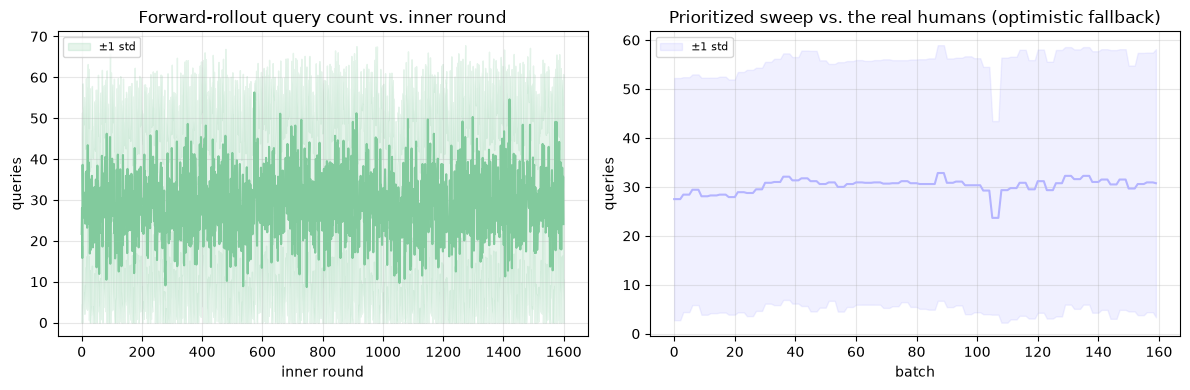

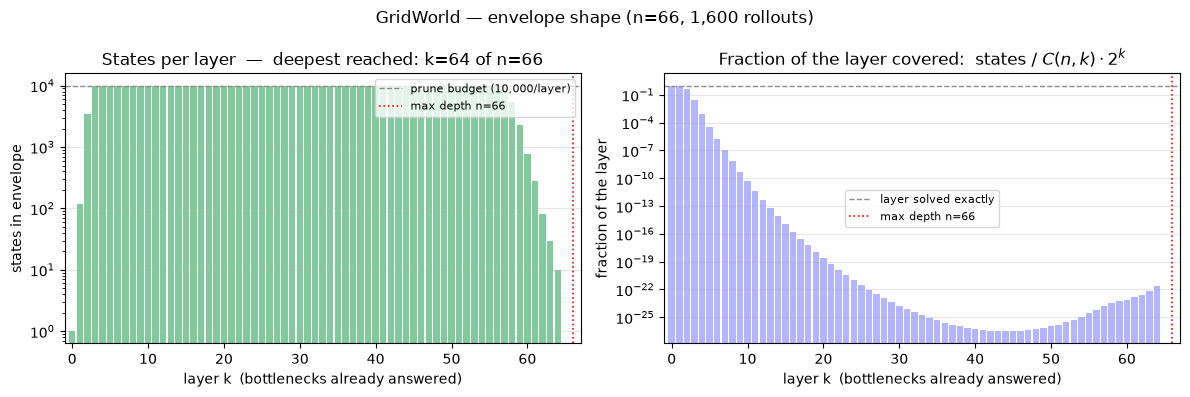

In [8]:
# Only the two plot helpers, never viz's own evaluate_policy_on_real_human: it is an
# older duplicate of the one bottlenecks.py exports.
from viz import plot_query_convergence, plot_envelope_shape

plot_query_convergence(
    trained["query_counts"], trained["human_query_counts_optimistic"],
    human_title="Prioritized sweep vs. the real humans (optimistic fallback)")

# keep = TOP_K * keep_margin, and keep_margin defaults to 10.0 -- the per-layer prune
# budget, so a flat top means the layer is capacity-limited rather than unreached.
plot_envelope_shape(
    pri_optimistic.envelope, keep=TOP_K * 10,
    title=f"GridWorld — envelope shape (n={len(B)}, {N_ROLLOUTS:,} rollouts)")
